In [1]:
# Cell 1: locate and list files
from pathlib import Path
import numpy as np

DATA_DIR = Path("data/warped-ifw")  # adjust if your cwd differs
files = sorted(DATA_DIR.glob("*.npz"))
print(f"Found {len(files)} .npz files")
print("First 10 filenames:")
for f in files[:10]:
    print(" ", f.name)

Found 905 .npz files
First 10 filenames:
  1021_1-0.npz
  1021_1-1.npz
  1021_1-2.npz
  1021_1-3.npz
  1021_1-4.npz
  1021_10-0.npz
  1021_10-1.npz
  1021_10-2.npz
  1021_10-3.npz
  1021_10-4.npz


In [11]:
# Cell 2: inspect one sample with full value printing
sample_path = files[0]
data = np.load(sample_path)

print(f"Inspecting: {sample_path.name}")
print(f"Keys: {list(data.keys())}\n")
print("=" * 60)

for key in data.keys():
    arr = data[key]
    print(f"\n{'=' * 60}")
    print(f"  Variable : {key}")
    print(f"  Shape    : {arr.shape}")
    print(f"  Dtype    : {arr.dtype}")
    print(f"  Min      : {np.nanmin(arr):.4g}")
    print(f"  Max      : {np.nanmax(arr):.4g}")
    print(f"  Values   :")
    print(arr)
    print(f"{'=' * 60}")

Inspecting: 1021_1-0.npz
Keys: ['t', 'pos', 'idcs_airfoil', 'pressure', 'velocity_in', 'velocity_out']


  Variable : t
  Shape    : (10,)
  Dtype    : float32
  Min      : 0.354
  Max      : 0.363
  Values   :
[0.354 0.355 0.356 0.357 0.358 0.359 0.36  0.361 0.362 0.363]

  Variable : pos
  Shape    : (100000, 3)
  Dtype    : float32
  Min      : -0.4053
  Max      : 2.094
  Values   :
[[ 1.6569071   0.09583618  0.75      ]
 [ 1.7194145   0.00208382  0.62499726]
 [ 1.6262949  -0.06177336  0.6868285 ]
 ...
 [ 0.8265631   0.00829163  0.13717332]
 [ 0.81320083  0.02713627  0.12096836]
 [ 0.8183516   0.0127282   0.12978129]]

  Variable : idcs_airfoil
  Shape    : (20000,)
  Dtype    : int32
  Min      : 104
  Max      : 1e+05
  Values   :
[  104   108   109 ... 99994 99998 99999]

  Variable : pressure
  Shape    : (10, 100000)
  Dtype    : float32
  Min      : -3656
  Max      : 1252
  Values   :
[[  69.587845 -117.71957  -325.134    ...  -41.968456   35.997093
   -29.448904]
 [  67.369

In [3]:
# Cell 3: heuristically classify arrays by shape
# A position array is typically (N, 3), N large (~1e5).
# A velocity/time-resolved field usually carries an extra time-like axis,
# e.g. (nt, N, 3) or (N, nt, 3).
# A boolean/0-1 array of shape (N,) is a plausible surface/boundary mask.

pos_key, vel_key, mask_key = None, None, None
for key in data.keys():
    arr = data[key]
    if arr.ndim == 2 and arr.shape[1] == 3 and arr.shape[0] > 1000:
        pos_key = key
    elif arr.ndim == 3 and 3 in arr.shape:
        vel_key = key
    elif arr.ndim == 1 and arr.dtype in (bool, np.bool_):
        mask_key = key

print(f"Guessed position array : {pos_key}")
print(f"Guessed velocity array : {vel_key}")
print(f"Guessed mask array     : {mask_key}")

Guessed position array : pos
Guessed velocity array : velocity_out
Guessed mask array     : None


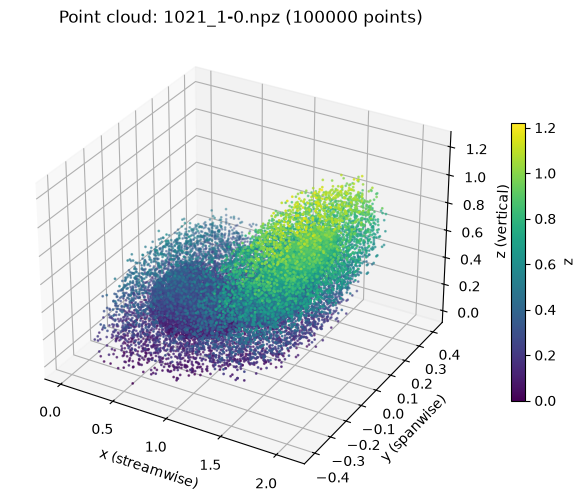

In [19]:
# Cell 4: plot geometry (point cloud) in 3D, colour by z for readability
import matplotlib.pyplot as plt

if pos_key is not None:
    pos = data[pos_key]
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], c=pos[:, 2], s=1, cmap="viridis")
    ax.set_xlabel("x (streamwise)")
    ax.set_ylabel("y (spanwise)")
    ax.set_zlabel("z (vertical)")
    ax.set_title(f"Point cloud: {sample_path.name} ({pos.shape[0]} points)")
    fig.colorbar(sc, shrink=0.6, label="z")
    plt.show()
else:
    print("No obvious (N,3) position array found, check the printed keys above.")

Time steps in this sample: 5


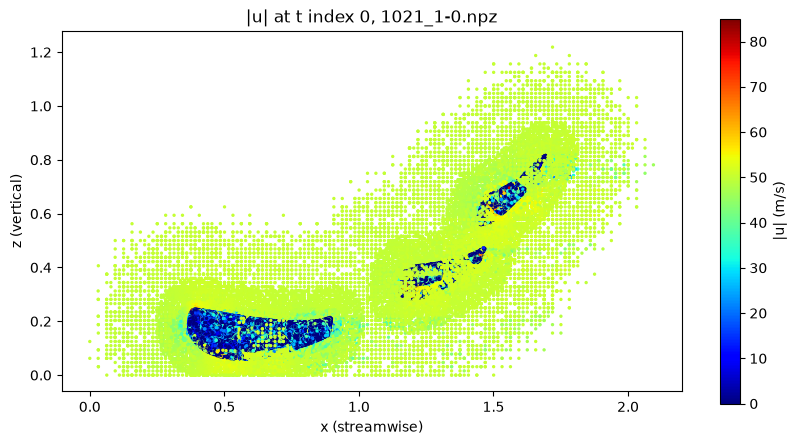

In [20]:
# Cell 5: plot velocity magnitude at one time slice, on the x-z plane
# (the paper's cross-section is in x-z, with a thin spanwise y extent)

if pos_key is not None and vel_key is not None:
    pos = data[pos_key]
    vel = data[vel_key]

    # Normalise to (nt, N, 3) regardless of which axis is time
    if vel.shape[1] == pos.shape[0]:
        vel_t_first = vel          # already (nt, N, 3)
    elif vel.shape[0] == pos.shape[0]:
        vel_t_first = vel.transpose(1, 0, 2)  # (N, nt, 3) -> (nt, N, 3)
    else:
        raise ValueError(f"Can't align vel shape {vel.shape} with pos shape {pos.shape}")

    nt = vel_t_first.shape[0]
    print(f"Time steps in this sample: {nt}")

    t_idx = 0  # first frame
    speed = np.linalg.norm(vel_t_first[t_idx], axis=-1)

    fig, ax = plt.subplots(figsize=(10, 5))
    sc = ax.scatter(pos[:, 0], pos[:, 2], c=speed, s=2, cmap="jet")
    ax.set_xlabel("x (streamwise)")
    ax.set_ylabel("z (vertical)")
    ax.set_aspect("equal")
    ax.set_title(f"|u| at t index {t_idx}, {sample_path.name}")
    fig.colorbar(sc, label="|u| (m/s)")
    plt.show()
else:
    print("Skipping velocity plot, check Cell 2/3 output to find the right key names.")

In [21]:
# Cell 6: sanity-check the file count against the paper
# Paper: 181 geometries, each simulated to t=0.5s with the window
# t ∈ [0.3, 0.5]s retained. 3006 files / 181 geometries ≈ 16.6,
# so files are very likely (geometry, time-window) pairs, not one file
# per geometry. Worth confirming from filenames:
import re
stems = [f.stem for f in files[:30]]
print("Sample filenames to check the naming pattern:")
for s in stems:
    print(" ", s)

Sample filenames to check the naming pattern:
  1021_1-0
  1021_1-1
  1021_1-2
  1021_1-3
  1021_1-4
  1021_10-0
  1021_10-1
  1021_10-2
  1021_10-3
  1021_10-4
  1021_11-0
  1021_11-1
  1021_11-2
  1021_11-3
  1021_11-4
  1021_12-0
  1021_12-1
  1021_12-2
  1021_12-3
  1021_12-4
  1021_13-0
  1021_13-1
  1021_13-2
  1021_13-3
  1021_13-4
  1021_14-0
  1021_14-1
  1021_14-2
  1021_14-3
  1021_14-4
